<a href="https://colab.research.google.com/github/HTKhuongNinh-FPTU/MachineLearning-Doc/blob/main/LAB_Logistic_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Library Imports & Data Loading

In [82]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from google.colab import files
import os
print("upload: train.csv và test.csv")
uploaded = files.upload()
train_file_name = next((f for f in uploaded.keys() if 'train.csv' in f), 'train.csv')
test_file_name = next((f for f in uploaded.keys() if 'test.csv' in f), 'test.csv')
data = pd.read_csv(train_file_name)
df_test = pd.read_csv(test_file_name)
print("Đã load xong 2 file!")

upload: train.csv và test.csv


Saving test.csv to test (12).csv
Saving train.csv to train (12).csv
Đã load xong 2 file!


Data Preprocessing & Splitting

In [83]:
data['Age'] = data['Age'].fillna(data['Age'].median())
data['Fare'] = data['Fare'].fillna(data['Fare'].median())

data['Sex'] = data['Sex'].map({'male': 0, 'female': 1})

mode_value = data['Sex'].mode()[0] if not data['Sex'].mode().empty else 0
data['Sex'] = data['Sex'].fillna(mode_value)

features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare']
X = data[features].values
y = data['Survived'].values

X_temp, X_test_lab, y_temp, y_test_lab = train_test_split(X, y, test_size=0.125, random_state=2)

X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.2, random_state=2)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test_lab = scaler.transform(X_test_lab)

X_train = np.c_[np.ones(X_train.shape[0]), X_train]
X_val = np.c_[np.ones(X_val.shape[0]), X_val]
X_test_lab = np.c_[np.ones(X_test_lab.shape[0]), X_test_lab]

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test_lab: {X_test_lab.shape})")

Train: (623, 7), Val: (156, 7), Test_lab: (112, 7))


Core Functions Implementation

In [88]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))
def predict(X, theta):
    return sigmoid(np.dot(X, theta))
def compute_loss(y, y_pred):
    y_pred = np.clip(y_pred, 1e-15, 1 - 1e-15)
    return -np.mean(y * np.log(y_pred) + (1 - y) * np.log(1 - y_pred))
def compute_gradient(X, y, y_pred):
    return np.dot(X.T, (y_pred - y)) / len(y)
def compute_accuracy(y, y_pred):
    return np.mean((y_pred >= 0.5).astype(int) == y)

Training Loop

In [85]:
lr = 0.005
epochs = 100
batch_size = 32

theta = np.zeros(X_train.shape[1])
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

for epoch in range(epochs):

    indices = np.random.permutation(len(X_train))
    X_shuffled = X_train[indices]
    y_shuffled = y_train[indices]


    for i in range(0, len(X_train), batch_size):
        X_batch = X_shuffled[i:i+batch_size]
        y_batch = y_shuffled[i:i+batch_size]

        y_pred = predict(X_batch, theta)
        gradient = compute_gradient(X_batch, y_batch, y_pred)
        theta -= lr * gradient


    train_pred = predict(X_train, theta)
    val_pred = predict(X_val, theta)

    history['train_loss'].append(compute_loss(y_train, train_pred))
    history['val_loss'].append(compute_loss(y_val, val_pred))
    history['train_acc'].append(compute_accuracy(y_train, train_pred))
    history['val_acc'].append(compute_accuracy(y_val, val_pred))

print("Huấn luyện hoàn tất!")

Huấn luyện hoàn tất!


Evaluation & Visualization

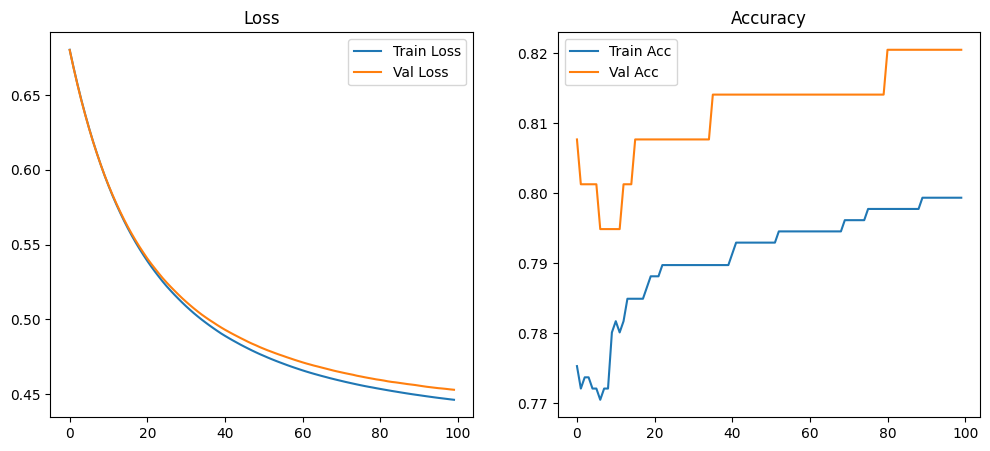

---------------------------------------------------
Accuracy trên tập Test-lab: 74.11%
---------------------------------------------------


In [95]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.legend(); plt.title('Loss')

plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Acc')
plt.plot(history['val_acc'], label='Val Acc')
plt.legend(); plt.title('Accuracy')
plt.show()

test_pred = predict(X_test_lab, theta)
print("---------------------------------------------------")
print(f"Accuracy trên tập Test-lab: {compute_accuracy(y_test_lab, test_pred)*100:.2f}%")
print("---------------------------------------------------")

Prediction & Submission File Generation

In [87]:
df_test_clean = df_test.copy()
df_test_clean['Age'] = df_test_clean['Age'].fillna(data['Age'].median())
df_test_clean['Fare'] = df_test_clean['Fare'].fillna(data['Fare'].median())
df_test_clean['Sex'] = df_test_clean['Sex'].map({'male': 0, 'female': 1})

features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare']
X_test_final = df_test_clean[features].values

X_test_final = scaler.transform(X_test_final)

X_test_final = np.c_[np.ones(X_test_final.shape[0]), X_test_final]

final_predictions = (predict(X_test_final, theta) >= 0.5).astype(int)

submission = pd.DataFrame({
    'PassengerId': df_test['PassengerId'],
    'Survived': final_predictions.flatten()
})
submission.to_csv('submission.csv', index=False)
print("Đã tạo file 'submission.csv' thành công!")
print(submission.head())

Đã tạo file 'submission.csv' thành công!
   PassengerId  Survived
0          892         0
1          893         0
2          894         0
3          895         0
4          896         1
